# 00 - Method validation

A single material (Si) and a single model (MACE-MP-0). The question is not
"what is the frequency?" but **"is my method correct?"**.

The common methodological choices are validated here. Material-dependent supercell and primitive matrices are inherited from each PBE reference, while numerical precision follows the native/recommended setting of each MLIP.

Environment: **MACE** (`requirements/mace.txt`).


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.paths import RESULTS, REFERENCE, FIGURES
import src.materials as M

In [2]:
from mace.calculators import mace_mp
import torch

calc = mace_mp(model="medium", default_dtype="float64", device="cuda")  # "cpu" if you do not have a GPU

# Which checkpoint was actually downloaded: "medium" resolves to different files
# depending on the mace-torch version, and the versions differ specifically in
# phonon stiffness. This must be recorded.
import mace
print("mace-torch:", mace.__version__)
print("default dtype:", torch.get_default_dtype())


c:\Users\antoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\e3nn\o3\_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with C:\Users\antoj\.cache\mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


c:\Users\antoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\mace\calculators\mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=model_path,

Using head Default out of ['Default']
mace-torch: 0.3.14
default dtype: torch.float64


In [3]:
from ase.spacegroup.symmetrize import check_symmetry
from src.reference import load_reference
from src.phonons import ph_to_ase, relax

ph_ref = load_reference(
    149,
    functional="pbe",
    use_nac=False,
)

atoms = ph_to_ase(ph_ref.unitcell)

print("Before relaxation:")
sym_before = check_symmetry(
    atoms,
    symprec=1e-5,
    verbose=False,
)
print(sym_before.international, sym_before.number)

relaxed = relax(
    atoms,
    calc,
    fmax=0.005,
    fix_symmetry=True,
    logfile=None,
)

print("\nAfter relaxation:")
sym_after = check_symmetry(
    relaxed,
    symprec=1e-5,
    verbose=False,
)
print(sym_after.international, sym_after.number)

print("\nCell lengths:")
print(relaxed.cell.lengths())

print("Cell angles:")
print(relaxed.cell.angles())


Before relaxation:
Fd-3m 227

After relaxation:
Fd-3m 227

Cell lengths:
[5.45497661 5.45497661 5.45497661]
Cell angles:
[90. 90. 90.]


In [4]:
from ase.spacegroup.symmetrize import check_symmetry

for key, meta in M.MATERIALS.items():

    ref = load_reference(
        meta["mp_id"],
        functional="pbe",
        use_nac=False,
    )

    atoms = ph_to_ase(ref.unitcell)

    before = check_symmetry(
        atoms,
        symprec=1e-4,
        verbose=False,
    )

    relaxed = relax(
        atoms,
        calc,
        fmax=0.005,
        fix_symmetry=True,
        logfile=None,
    )

    after = check_symmetry(
        relaxed,
        symprec=1e-4,
        verbose=False,
    )

    print(
        f"{key:5s}: "
        f"{before.international} ({before.number})"
        f" -> "
        f"{after.international} ({after.number})"
    )

Si   : Fd-3m (227) -> Fd-3m (227)
SiC  : F-43m (216) -> F-43m (216)
AlP  : F-43m (216) -> F-43m (216)
ZnS  : F-43m (216) -> F-43m (216)
MgO  : Fm-3m (225) -> Fm-3m (225)
NaCl : Fm-3m (225) -> Fm-3m (225)
AlN  : P6_3mc (186) -> P6_3mc (186)
GaN  : P6_3mc (186) -> P6_3mc (186)


In [5]:
from src.phonons import compute_phonons
ph_ref = load_reference(
    149,
    functional="pbe",
    use_nac=False,
)

atoms = ph_to_ase(ph_ref.unitcell)

ph_test, relaxed = compute_phonons(
    atoms,
    calc,
    supercell_matrix=ph_ref.supercell_matrix,
    primitive_matrix=ph_ref.primitive_matrix,
    disp=0.01,
    fmax=0.005,
    fix_symmetry=True,
    logfile=None,
)

print("Reference supercell matrix:")
print(ph_ref.supercell_matrix)

print("\nMLIP supercell matrix:")
print(ph_test.supercell_matrix)

print("\nReference primitive matrix:")
print(ph_ref.primitive_matrix)

print("\nMLIP primitive matrix:")
print(ph_test.primitive_matrix)

print("\nReference supercell atoms:", len(ph_ref.supercell))
print("MLIP supercell atoms:", len(ph_test.supercell))

Reference supercell matrix:
[[2 0 0]
 [0 2 0]
 [0 0 2]]

MLIP supercell matrix:
[[2 0 0]
 [0 2 0]
 [0 0 2]]

Reference primitive matrix:
[[0.  0.5 0.5]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]]

MLIP primitive matrix:
[[0.  0.5 0.5]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]]

Reference supercell atoms: 64
MLIP supercell atoms: 64


In [6]:
from src.phonons import (
    commensurate_frequencies,
    max_frequency,
    has_imaginary,
)

q_comm, freq_comm = commensurate_frequencies(ph_test)

print("Number of commensurate q-points:", len(q_comm))

print("\nq-points:")
print(q_comm)

print(
    "\ncommensurate omega_max:",
    f"{max_frequency(ph_test):.4f} THz",
)

print(
    "dynamically unstable:",
    has_imaginary(ph_test),
)


Number of commensurate q-points: 8

q-points:
[[0.  0.  0. ]
 [0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.5 0.5 0. ]
 [0.  0.  0.5]
 [0.5 0.  0.5]
 [0.  0.5 0.5]
 [0.5 0.5 0.5]]

commensurate omega_max: 11.1898 THz
dynamically unstable: False


In [7]:
import numpy as np

# Only to illustrate the methodological difference.
ph_test.run_mesh(
    [20, 20, 20],
    is_gamma_center=True,
)

omega_dense = float(
    np.max(ph_test.mesh.frequencies)
)

omega_comm = max_frequency(ph_test)

print(f"omega_max commensurate : {omega_comm:.4f} THz")
print(f"omega_max dense 20^3   : {omega_dense:.4f} THz")
print(f"difference             : {omega_dense - omega_comm:+.4f} THz")


omega_max commensurate : 11.1898 THz
omega_max dense 20^3   : 11.1898 THz
difference             : +0.0000 THz


## Common PBE band path

In [8]:
from src.phonons import make_band_path, band_structure

ph_ref = load_reference(
    149,
    functional="pbe",
    use_nac=False,
)

band_path = make_band_path(
    ph_ref,
    npoints=101,
)

bands_ref = band_structure(
    ph_ref,
    band_path,
)

bands_mlip = band_structure(
    ph_test,
    band_path,
)

print("Labels:")
print(band_path["labels"])

print("\nPath connections:")
print(band_path["path_connections"])

print("\nNumber of segments:")
print(len(band_path["qpoints"]))

Labels:
['$\\Gamma$', '$\\mathrm{X}$', '$\\mathrm{U}$', '$\\mathrm{K}$', '$\\Gamma$', '$\\mathrm{L}$', '$\\mathrm{W}$', '$\\mathrm{X}$']

Path connections:
[True, False, True, True, True, False]

Number of segments:
6


In [9]:
for i, (q_ref, q_mlip) in enumerate(
    zip(
        bands_ref["qpoints"],
        bands_mlip["qpoints"],
    )
):
    assert np.allclose(
        q_ref,
        q_mlip,
        atol=1e-12,
    ), f"Different q-points in segment {i}"

print("OK: DFT and MLIP use exactly the same q-points.")

OK: DFT and MLIP use exactly the same q-points.


In [10]:
for i, (d_ref, d_mlip) in enumerate(
    zip(
        bands_ref["distances"],
        bands_mlip["distances"],
    )
):
    assert np.allclose(
        d_ref,
        d_mlip,
        atol=1e-12,
    )

print("OK: DFT and MLIP share the same PBE reference x-axis.")

OK: DFT and MLIP share the same PBE reference x-axis.


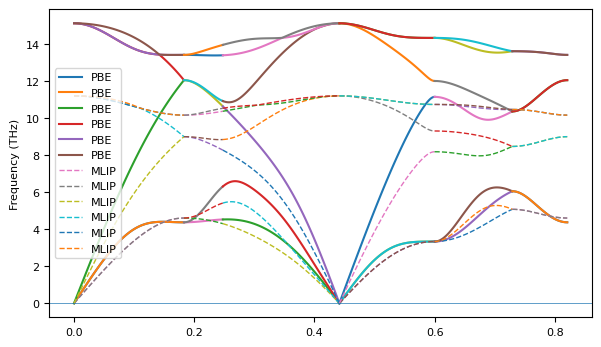

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

for i, (d, f) in enumerate(zip(
    bands_ref["distances"],
    bands_ref["frequencies"],
)):
    ax.plot(
        d,
        f,
        linewidth=1.5,
        label="PBE" if i == 0 else None,
    )

for i, (d, f) in enumerate(zip(
    bands_mlip["distances"],
    bands_mlip["frequencies"],
)):
    ax.plot(
        d,
        f,
        "--",
        linewidth=1.0,
        label="MLIP" if i == 0 else None,
    )

ax.axhline(0, linewidth=0.5)
ax.set_ylabel("Frequency (THz)")
ax.legend()

plt.show()

In [12]:
from src.phonons import gamma_frequencies, max_frequency, has_imaginary

mp_id = M.MATERIALS["Si"]["mp_id"]

ph_ref = load_reference(
    mp_id,
    functional="pbe",
    use_nac=False,
)

atoms = ph_to_ase(ph_ref.unitcell)
print(atoms, atoms.cell.cellpar())

ph, relaxed = compute_phonons(atoms, calc, supercell_matrix=ph_ref.supercell_matrix, primitive_matrix=ph_ref.primitive_matrix, disp=0.01, fmax=0.005, fix_symmetry=True)

print("relaxed cell [Å]:", relaxed.cell.cellpar()[:3].round(4))
print("Gamma frequencies (THz):", gamma_frequencies(ph).round(4))
print("omega_max (THz)         :", round(max_frequency(ph), 4))
print("imaginary modes?        :", has_imaginary(ph))


Atoms(symbols='Si8', pbc=True, cell=[5.467220385087693, 5.467220385087693, 5.467220385087693]) [ 5.46722039  5.46722039  5.46722039 90.         90.         90.        ]
relaxed cell [Å]: [5.455 5.455 5.455]
Gamma frequencies (THz): [-0.     -0.      0.     11.1898 11.1898 11.1898]
omega_max (THz)         : 11.1898
imaginary modes?        : False


### Expected checks

- **6 branches**: 2 atoms in the primitive cell -> 6 modes
- **3 acoustic modes at zero at Gamma**: they should be ~1e-7 THz (machine zero)
- **3 degenerate optical modes**: enforced by diamond symmetry
- **no imaginary modes**
- **lattice parameter** close to 5.43-5.47 Å


## Convergence with respect to supercell size

In the finite-displacement method, the harmonic force constants are reconstructed from the forces generated by small atomic displacements in a finite supercell.

The supercell size therefore introduces a spatial truncation of the interactions: by increasing the supercell, one can assess how strongly the calculated frequencies depend on this parameter.

For Si, a diagnostic test is performed using isotropic `2x2x2`, `3x3x3`, and `4x4x4` supercells. Since the Alexandria PBE unit cell for Si contains 8 atoms, these correspond to 64, 216, and 512 atoms, respectively.

This test **is not used to select a global supercell**. In production calculations, the `supercell_matrix` specific to the corresponding PBE reference is always reused, so as to preserve the same protocol as the DFT benchmark.


In [13]:
from src.phonons import convergence_test
import json

conv = convergence_test(
    atoms,
    calc,
    primitive_matrix=ph_ref.primitive_matrix,
    sizes=(2, 3, 4),
    disp=0.01,
    fmax=0.005,
    logfile=None,
)

for n, r in conv.items():
    print(
        f"{n}x{n}x{n}: "
        f"{r['n_atoms_supercell']:4d} atoms | "
        f"Gamma max = {r['omega_max_gamma']:.4f} THz | "
        f"omega max = {r['omega_max']:.4f} THz | "
        f"{r['runtime_s']:.2f}s"
    )

(RESULTS / "mace").mkdir(parents=True, exist_ok=True)
(RESULTS / "mace" / "_convergence_Si.json").write_text(json.dumps(conv, indent=2))

2x2x2:   64 atoms | Gamma max = 11.1898 THz | omega max = 11.1898 THz | 0.55s
3x3x3:  216 atoms | Gamma max = 11.1898 THz | omega max = 11.1898 THz | 2.30s
4x4x4:  512 atoms | Gamma max = 11.1898 THz | omega max = 11.1898 THz | 9.10s


1618

## Comparison with the DFT reference

The main reference used in this project is the **PBE dataset from the Alexandria phonon benchmark**, i.e. the same dataset constructed and used by Loew et al. to compare universal interatomic potentials.

This choice is important because MACE-MP-0, CHGNet, and M3GNet were trained primarily on DFT data compatible with PBE. Using the earlier PBEsol dataset as the main reference would therefore introduce a systematic difference due to the exchange-correlation functional in addition to the MLIP error.

The **PBEsol** version is nevertheless retained as a secondary comparison. The PBE-PBEsol difference provides an estimate of how much a vibrational property can change simply by changing the DFT level of theory.

For polar materials, the DFT reference may include the non-analytical correction responsible for LO-TO splitting, based on Born effective charges. The MLIPs considered here do not provide these quantities; to ensure a consistent comparison, the reference is therefore loaded with `use_nac=False`.

The main comparison is therefore:

**MLIP vs PBE**, with **PBEsol vs PBE** used only as an indication of sensitivity to the functional.


In [14]:
from src.reference import load_reference

# Main DFT reference used in Loew et al.
ph_ref = load_reference(
    149,
    functional="pbe",
    use_nac=False,
    expect="Si",
)

# Secondary reference: original PBEsol calculation
ph_ref_pbesol = load_reference(
    149,
    functional="pbesol",
    use_nac=False,
    expect="Si",
)

print("PBE reference: mp-149")

print(
    "supercell:",
    ph_ref.supercell_matrix.tolist(),
    "->",
    len(ph_ref.supercell),
    "atoms",
)

print(
    "primitive matrix:",
    ph_ref.primitive_matrix.tolist(),
)

print(
    "PBE cell [Å]:",
    ph_ref.unitcell.cell.diagonal().round(4),
)

print(
    "PBEsol cell [Å]:",
    ph_ref_pbesol.unitcell.cell.diagonal().round(4),
)

print(
    "Gamma PBE (THz):",
    gamma_frequencies(ph_ref).round(4),
)

print(
    "Gamma PBEsol (THz):",
    gamma_frequencies(ph_ref_pbesol).round(4),
)


PBE reference: mp-149
supercell: [[2, 0, 0], [0, 2, 0], [0, 0, 2]] -> 64 atoms
primitive matrix: [[0.0, 0.5, 0.5], [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]]
PBE cell [Å]: [5.4672 5.4672 5.4672]
PBEsol cell [Å]: [5.4346 5.4346 5.4346]
Gamma PBE (THz): [-0.      0.      0.     15.1074 15.1074 15.1074]
Gamma PBEsol (THz): [ 0.      0.      0.     15.2872 15.2872 15.2872]


In [15]:
g_mace = gamma_frequencies(ph)[-1]
g_dft = gamma_frequencies(ph_ref)[-1]
print(f"Gamma optical  MACE {g_mace:7.3f} THz   DFT {g_dft:7.3f} THz   "
      f"deviation {100*(g_mace-g_dft)/g_dft:+.1f}%")


Gamma optical  MACE  11.190 THz   DFT  15.107 THz   deviation -25.9%


In [16]:
from ase.spacegroup.symmetrize import check_symmetry

for key, meta in M.MATERIALS.items():
    ref = load_reference(
        meta["mp_id"],
        functional="pbe",
        use_nac=False,
    )

    atoms = ph_to_ase(ref.unitcell)

    before = check_symmetry(
        atoms,
        symprec=1e-4,
        verbose=False,
    )

    relaxed = relax(
        atoms,
        calc,
        fmax=0.005,
        fix_symmetry=True,
        logfile=None,
    )

    after = check_symmetry(
        relaxed,
        symprec=1e-4,
        verbose=False,
    )

    ok = before.number == after.number

    print(
        f"{key:5s}: "
        f"{before.international} ({before.number}) "
        f"-> {after.international} ({after.number}) "
        f"{'OK' if ok else 'FAIL'}"
    )

    assert ok, f"{key}: space group changed during CHGNet relaxation"

Si   : Fd-3m (227) -> Fd-3m (227) OK
SiC  : F-43m (216) -> F-43m (216) OK
AlP  : F-43m (216) -> F-43m (216) OK
ZnS  : F-43m (216) -> F-43m (216) OK
MgO  : Fm-3m (225) -> Fm-3m (225) OK
NaCl : Fm-3m (225) -> Fm-3m (225) OK
AlN  : P6_3mc (186) -> P6_3mc (186) OK
GaN  : P6_3mc (186) -> P6_3mc (186) OK


## Validation conclusions

- the pipeline produces correct dispersions for Si
- the `2x2x2` / `3x3x3` / `4x4x4` test shows the sensitivity of the method
  to the supercell size; in production runs, the `supercell_matrix` specific
  to the PBE reference is nevertheless always reused
- fixed parameters: `2x2x2` supercell, 0.01 Å displacement, Gamma-centered `20x20x20` mesh
- the residual discrepancy relative to DFT is not a numerical error but the
  model prediction (see *systematic softening*, Deng et al., npj Comput. Mater. 11, 9 (2025))
